# Ablation: Parse Error Self-Correction (Retry Feedback)

Compares game completion rates **with** and **without** a retry mechanism that feeds parse errors back to the model (like tool-use feedback) and lets it correct its response.

- **Baseline**: `max_retries=0` — parse errors crash the game immediately
- **Retry3**: `max_retries=3` — model gets up to 3 attempts to fix its output, with specific error messages

In [51]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 18})
sns.set(font_scale=1.8)

BASELINE_ROOT = "../../.logs/small_models/section_one"
RETRY_ROOT = "../../.logs"

GAME_DIRS = {
    "BuySell": ("buysell_section_one", "buysell_section_one_retry3"),
    "Trading": ("trading_section_one", "trading_section_one_retry3"),
    "Ultimatum": ("ultimatum_section_one", "ultimatum_section_one_retry3"),
}

os.makedirs("../figures", exist_ok=True)

In [52]:
def scan_games(log_dir):
    rows = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            states = data["game_state"]
            last = states[-1]
            completed = last.get("current_iteration") == "END"
            players = data["players"]
            model_1 = players[0].get("model_id", players[0].get("model", "unknown"))
            model_2 = players[1].get("model_id", players[1].get("model", "unknown"))

            # Extract retry info from non-START, non-END states
            turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
            retries_per_turn = [s.get("parse_retries", 0) for s in turn_states]
            total_retries = sum(r for r in retries_per_turn if isinstance(r, int))
            max_retries_in_game = max((r for r in retries_per_turn if isinstance(r, int)), default=0)

            rows.append({
                "path": path,
                "model_1": model_1.split("/")[-1],
                "model_2": model_2.split("/")[-1],
                "completed": completed,
                "num_turns": len(turn_states),
                "total_retries": total_retries,
                "max_retries_in_game": max_retries_in_game,
                "retries_per_turn": retries_per_turn,
            })
        except Exception as e:
            pass
    return pd.DataFrame(rows)


# Load all data
all_rows = []
for game_name, (baseline_dir, retry_dir) in GAME_DIRS.items():
    bl = scan_games(os.path.join(BASELINE_ROOT, baseline_dir))
    bl["condition"] = "Baseline"
    bl["game"] = game_name

    rt = scan_games(os.path.join(RETRY_ROOT, retry_dir))
    rt["condition"] = "Retry (n=3)"
    rt["game"] = game_name

    all_rows.append(bl)
    all_rows.append(rt)

df = pd.concat(all_rows, ignore_index=True)
df["pairing"] = df["model_1"] + "\nvs " + df["model_2"]

print(f"Total game files loaded: {len(df)}")
print(f"\nPer condition:")
print(df.groupby(["game", "condition"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).to_string())

Total game files loaded: 1819

Per condition:
                       total  completed
game      condition                    
BuySell   Baseline       480         13
          Retry (n=3)    117         58
Trading   Baseline       480        209
          Retry (n=3)     90         52
Ultimatum Baseline       480        262
          Retry (n=3)    172        143


## 1. Game Completion Rate: Baseline vs Retry

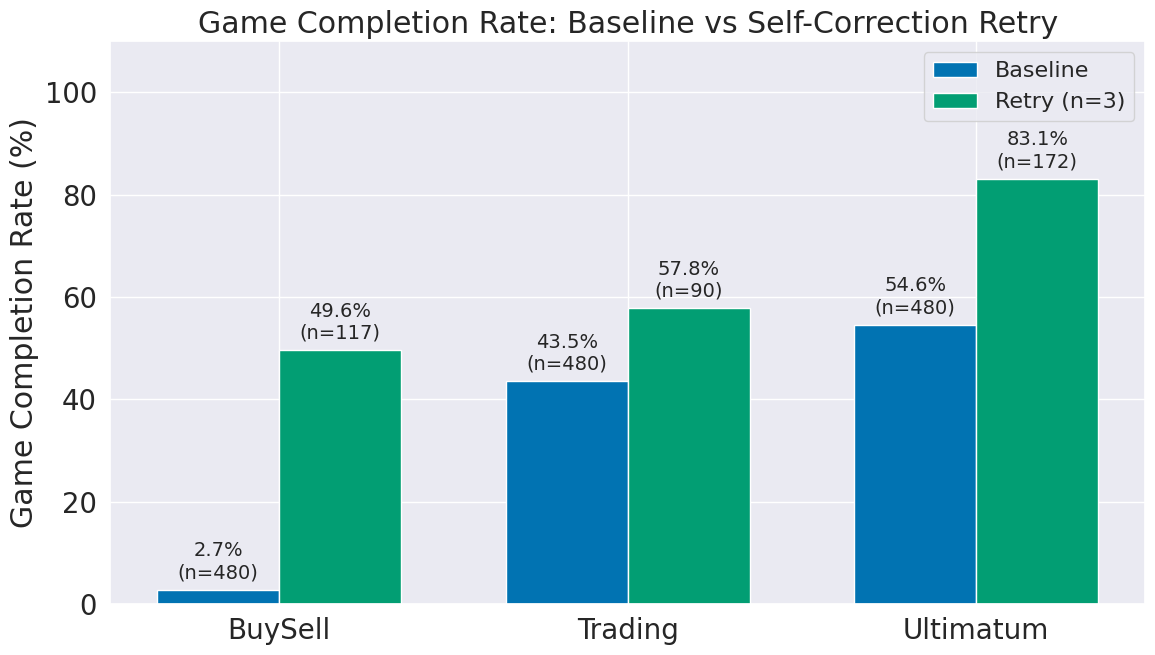

In [53]:
#  Completion rate by game type (aggregate) 
agg = df.groupby(["game", "condition"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = sorted(agg["game"].unique())
conditions = ["Baseline", "Retry (n=3)"]
x = np.arange(len(games))
width = 0.35
colors = {"Baseline": sns.color_palette("colorblind")[0], "Retry (n=3)": sns.color_palette("colorblind")[2]}

fig, ax = plt.subplots(figsize=(12, 7))
for i, cond in enumerate(conditions):
    sub = agg[agg["condition"] == cond].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    totals = [f'n={int(sub.loc[g, "total"])}' if g in sub.index else "" for g in games]
    bars = ax.bar(x + i * width, vals, width, label=cond, color=colors[cond])
    for bar, val, total in zip(bars, vals, totals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                f"{val:.1f}%\n({total})", ha="center", va="bottom", fontsize=14)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("Game Completion Rate (%)")
ax.set_title("Game Completion Rate: Baseline vs Self-Correction Retry")
ax.set_ylim(0, 110)
ax.legend(fontsize=16)
fig.tight_layout()
plt.savefig("../figures/retry_ablation_completion_rate.pdf", bbox_inches="tight")
plt.show()

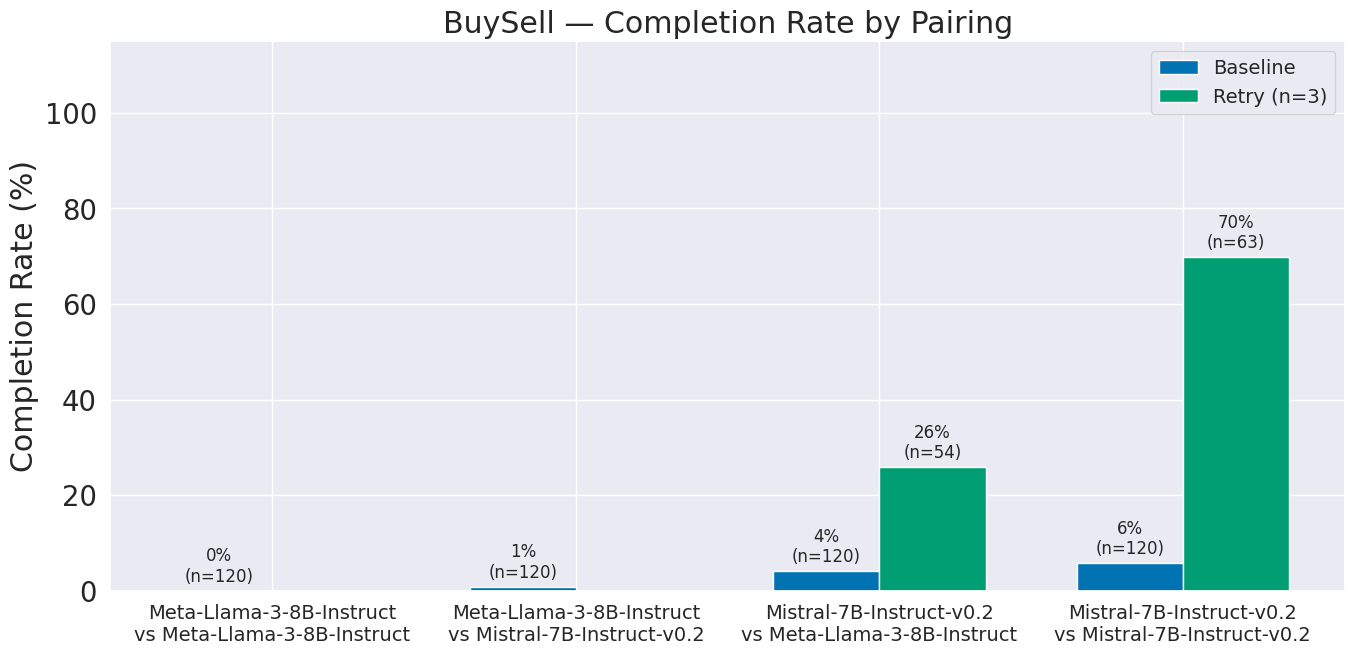

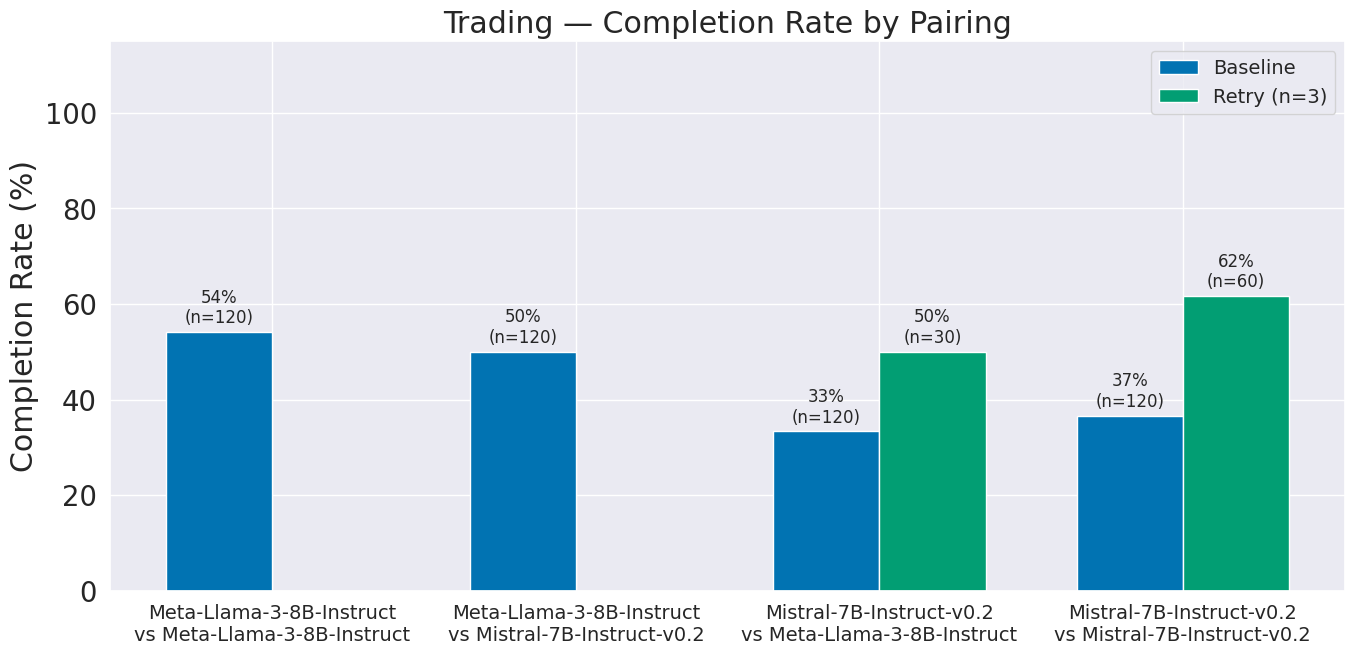

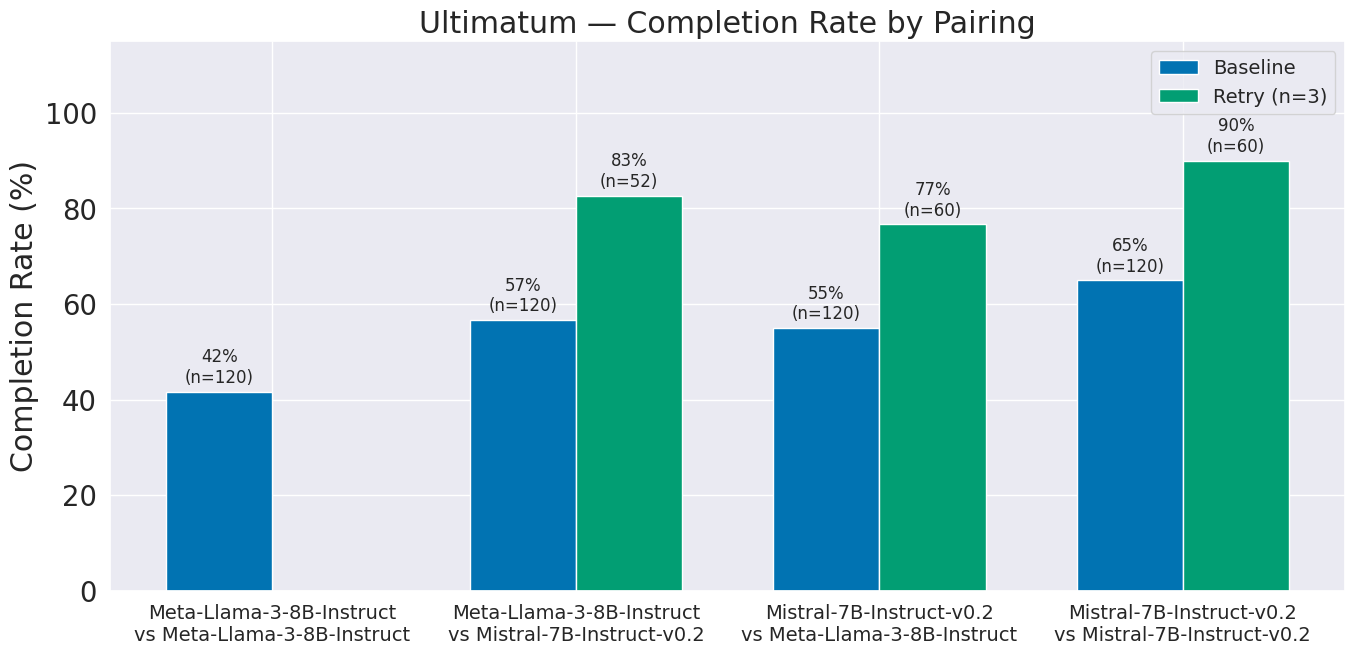

In [54]:
#  Completion rate by game type AND pairing 
agg_pair = df.groupby(["game", "condition", "pairing"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg_pair["pct"] = agg_pair["completed"] / agg_pair["total"] * 100

for game_name in games:
    sub = agg_pair[agg_pair["game"] == game_name]
    pairings = sorted(sub["pairing"].unique())
    x = np.arange(len(pairings))

    fig, ax = plt.subplots(figsize=(max(10, len(pairings) * 3.5), 7))
    for i, cond in enumerate(conditions):
        csub = sub[sub["condition"] == cond].set_index("pairing")
        vals = [csub.loc[p, "pct"] if p in csub.index else 0 for p in pairings]
        totals = [int(csub.loc[p, "total"]) if p in csub.index else 0 for p in pairings]
        bars = ax.bar(x + i * width, vals, width, label=cond, color=colors[cond])
        for bar, val, tot in zip(bars, vals, totals):
            if tot > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
                        f"{val:.0f}%\n(n={tot})", ha="center", va="bottom", fontsize=12)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(pairings, fontsize=14)
    ax.set_ylabel("Completion Rate (%)")
    ax.set_title(f"{game_name} — Completion Rate by Pairing")
    ax.set_ylim(0, 115)
    ax.legend(fontsize=14)
    fig.tight_layout()
    plt.savefig(f"../figures/retry_ablation_{game_name.lower()}_by_pairing.pdf", bbox_inches="tight")
    plt.show()

## 2. Retry Analysis

How often did the retry mechanism fire, and did it actually help?

In [55]:
#  Retry stats (only retry condition has parse_retries data) 
df_retry = df[df["condition"] == "Retry (n=3)"].copy()

for game_name in games:
    gsub = df_retry[df_retry["game"] == game_name]
    total_games = len(gsub)
    games_with_retries = (gsub["total_retries"] > 0).sum()
    completed = gsub["completed"].sum()
    total_retry_turns = gsub["total_retries"].sum()

    print(f" {game_name} ")
    print(f"  Games: {total_games} total, {int(completed)} completed ({completed/total_games*100:.1f}%)")
    print(f"  Games needing retries: {games_with_retries}/{total_games} ({games_with_retries/total_games*100:.1f}%)")
    print(f"  Total retry turns across all games: {int(total_retry_turns)}")

    # Of games that needed retries, how many completed?
    retry_games = gsub[gsub["total_retries"] > 0]
    if len(retry_games) > 0:
        retry_completed = retry_games["completed"].sum()
        print(f"  Games with retries that completed: {int(retry_completed)}/{len(retry_games)} ({retry_completed/len(retry_games)*100:.1f}%)")
    print()

 BuySell 
  Games: 117 total, 58 completed (49.6%)
  Games needing retries: 41/117 (35.0%)
  Total retry turns across all games: 103
  Games with retries that completed: 30/41 (73.2%)

 Trading 
  Games: 90 total, 52 completed (57.8%)
  Games needing retries: 24/90 (26.7%)
  Total retry turns across all games: 39
  Games with retries that completed: 21/24 (87.5%)

 Ultimatum 
  Games: 172 total, 143 completed (83.1%)
  Games needing retries: 44/172 (25.6%)
  Total retry turns across all games: 72
  Games with retries that completed: 41/44 (93.2%)



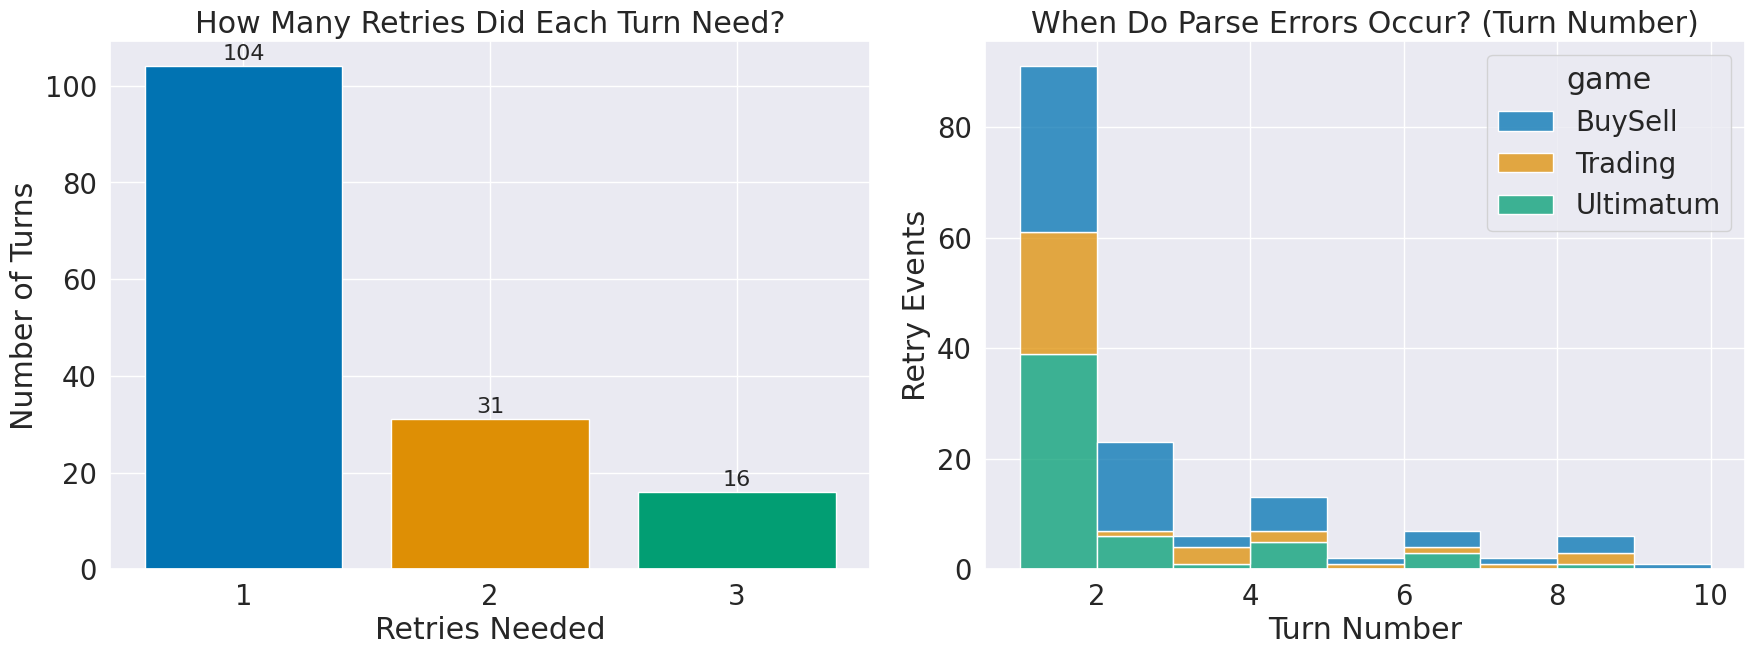

In [56]:
#  Distribution of retries needed per turn 
# Flatten: one row per turn that needed retries
retry_turn_rows = []
for _, row in df_retry.iterrows():
    for turn_idx, retries in enumerate(row["retries_per_turn"]):
        if isinstance(retries, int) and retries > 0:
            retry_turn_rows.append({
                "game": row["game"],
                "pairing": row["pairing"],
                "completed": row["completed"],
                "turn_idx": turn_idx + 1,
                "retries_needed": retries,
            })

df_turns = pd.DataFrame(retry_turn_rows)

if len(df_turns) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Left: Distribution of retries needed per turn
    ax = axes[0]
    counts = df_turns["retries_needed"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette("colorblind"))
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                str(val), ha="center", va="bottom", fontsize=16)
    ax.set_xlabel("Retries Needed")
    ax.set_ylabel("Number of Turns")
    ax.set_title("How Many Retries Did Each Turn Need?")
    ax.set_xticks([1, 2, 3])

    # Right: At which turn (early vs late) do retries occur?
    ax = axes[1]
    sns.histplot(data=df_turns, x="turn_idx", hue="game", multiple="stack",
                 bins=range(1, df_turns["turn_idx"].max() + 2), ax=ax, palette="colorblind")
    ax.set_xlabel("Turn Number")
    ax.set_ylabel("Retry Events")
    ax.set_title("When Do Parse Errors Occur? (Turn Number)")

    fig.tight_layout()
    plt.savefig("../figures/retry_ablation_retry_distribution.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No retry data found.")

## 3. Retry Success Rate by Attempt Number

For turns where retry 1 was needed: did it fix the parse?  
For turns where retry 2 was needed (retry 1 failed): did retry 2 fix it?  
etc.

 Retry Success by Attempt Number 

Total turns entering retry loop: ~277
  (=151 succeeded after retries + ~126 exhausted all retries)

Attempt 1: 104/277 succeeded (37.5%)
Attempt 2: 31/173 succeeded (17.9%)
Attempt 3: 16/142 succeeded (11.3%)

Exhausted all 3 retries (still failed): ~126


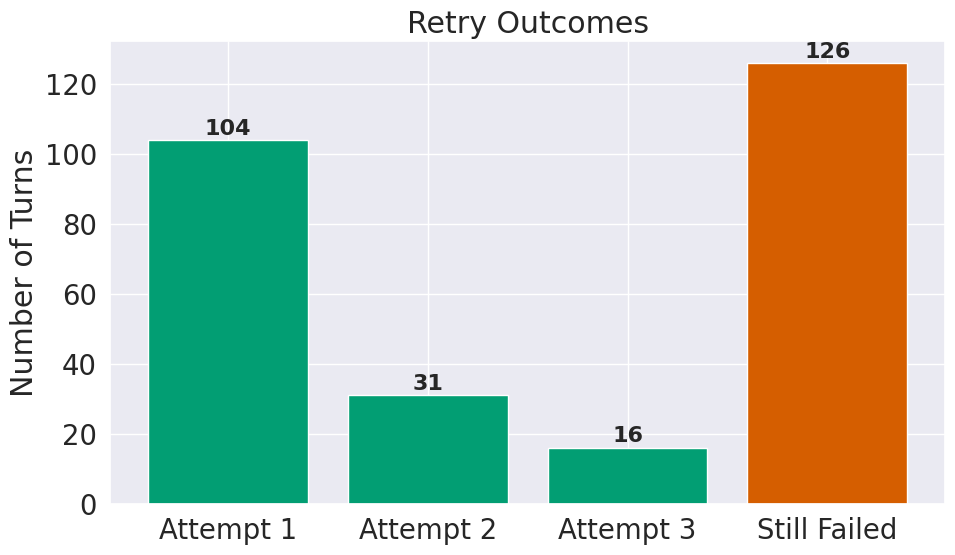

In [57]:
if len(df_turns) > 0:
    succeeded_at = df_turns["retries_needed"].value_counts().sort_index()

    incomplete_retry = df_retry[~df_retry["completed"] & (df_retry["total_retries"] > 0)]
    estimated_exhausted = len(df_retry[~df_retry["completed"]])

    print(" Retry Success by Attempt Number \n")
    # Total turns that entered retry: those that succeeded + estimated exhausted
    total_retry_events = len(df_turns) + estimated_exhausted

    print(f"Total turns entering retry loop: ~{total_retry_events}")
    print(f"  (={len(df_turns)} succeeded after retries + ~{estimated_exhausted} exhausted all retries)\n")

    # Attempt 1: all retry events enter attempt 1
    attempt_1_success = (df_turns["retries_needed"] == 1).sum()
    attempt_1_total = total_retry_events
    print(f"Attempt 1: {attempt_1_success}/{attempt_1_total} succeeded ({attempt_1_success/attempt_1_total*100:.1f}%)")

    # Attempt 2: those where attempt 1 failed
    attempt_2_entered = attempt_1_total - attempt_1_success
    attempt_2_success = (df_turns["retries_needed"] == 2).sum()
    if attempt_2_entered > 0:
        print(f"Attempt 2: {attempt_2_success}/{attempt_2_entered} succeeded ({attempt_2_success/attempt_2_entered*100:.1f}%)")

    # Attempt 3: those where attempt 2 also failed
    attempt_3_entered = attempt_2_entered - attempt_2_success
    attempt_3_success = (df_turns["retries_needed"] == 3).sum()
    if attempt_3_entered > 0:
        print(f"Attempt 3: {attempt_3_success}/{attempt_3_entered} succeeded ({attempt_3_success/attempt_3_entered*100:.1f}%)")

    # Still failed after 3
    still_failed = attempt_3_entered - attempt_3_success
    print(f"\nExhausted all 3 retries (still failed): ~{still_failed}")

    fig, ax = plt.subplots(figsize=(10, 6))
    attempt_labels = ["Attempt 1", "Attempt 2", "Attempt 3", "Still Failed"]
    attempt_vals = [attempt_1_success, attempt_2_success, attempt_3_success, still_failed]
    bar_colors = [sns.color_palette("colorblind")[2]] * 3 + [sns.color_palette("colorblind")[3]]
    bars = ax.bar(attempt_labels, attempt_vals, color=bar_colors)
    for bar, val in zip(bars, attempt_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                str(val), ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylabel("Number of Turns")
    ax.set_title("Retry Outcomes")
    fig.tight_layout()
    plt.savefig("../figures/retry_ablation_attempt_success.pdf", bbox_inches="tight")
    plt.show()